In [1]:
from bh_molecule.instruments import Vis133M

In [2]:
s = Vis133M.from_files("193791.fits")

In [3]:
s.apply_cw(cw_nm=431.92)
s.calibration_report()

Vis133M calibration report
--------------------------
FITS file: 193791.fits

CW determination:
  method: manual
  CW used: 431.92 nm

Reference calibration:
  reference CW: 433.26 nm
  ΔCW applied: -1.34 nm

Spectral axis:
  data pixels: 2048
  calibration pixels: 1024
  binning factor: 2.0

Polynomial:
  order: 2


In [10]:
fig = s.plot_spectrum_plotly(10, 30)
fig.show()

```python
s.set_scale(0.0001837)
s.set_dark(frame=49, channel=43)
s.set_baseline_zero(True)
s.set_time_linspace(0, 10)
```

<Axes: xlabel='frame', ylabel='channel'>

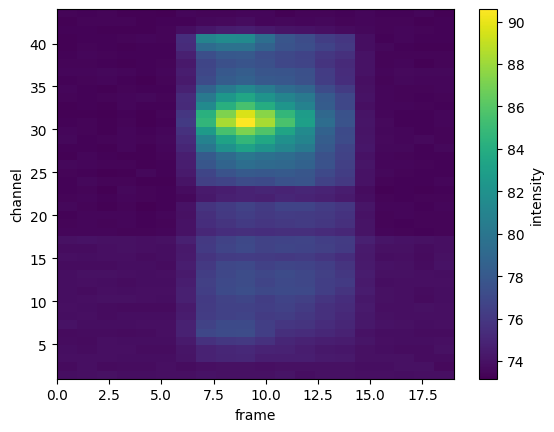

In [11]:
s.plot_band_map([433,433.5])

In [16]:
# Scale the intensity from thosands to ~1 for better fitting
s.set_scale(0.0001837) 
s.set_dark(frame=18)
s.set_baseline_zero(True)
s.set_time_linspace(0,10)

In [17]:
from bh_molecule.physics import BHModel
from bh_molecule.fit import BHFitter
model = BHModel()

,Parameter,Value
0,C,0.50 ± 0.03
1,T_rot,1800 ± 100 K
2,dx,(0 ± 9)e-4 nm
3,w_inst,0.029 ± 0.002 nm
4,base,0.025 ± 0.002
5,I_R7,(4 ± 3)e-4
6,I_R8,(5 ± 3)e-4


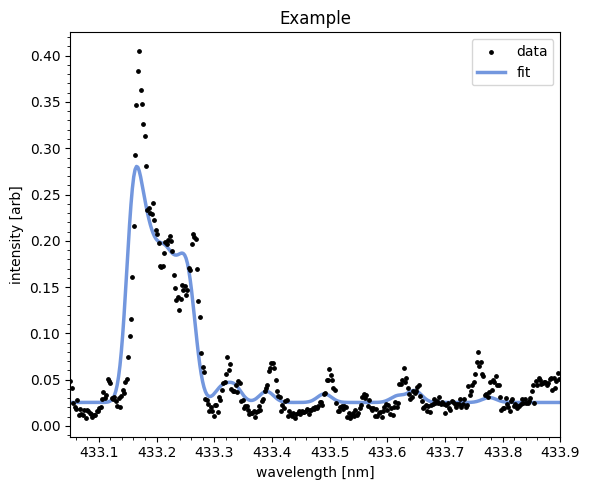

In [19]:
fitr = BHFitter(s, model, warm_start=True, weight="none")
res = fitr.fit(frame=9, channel=31)
display(res["summary"])
_ = fitr.plot_single(res, title="Example")

In [20]:
resb,curves = fitr.batch((7,8,9), (30,31,32),return_curves=True)

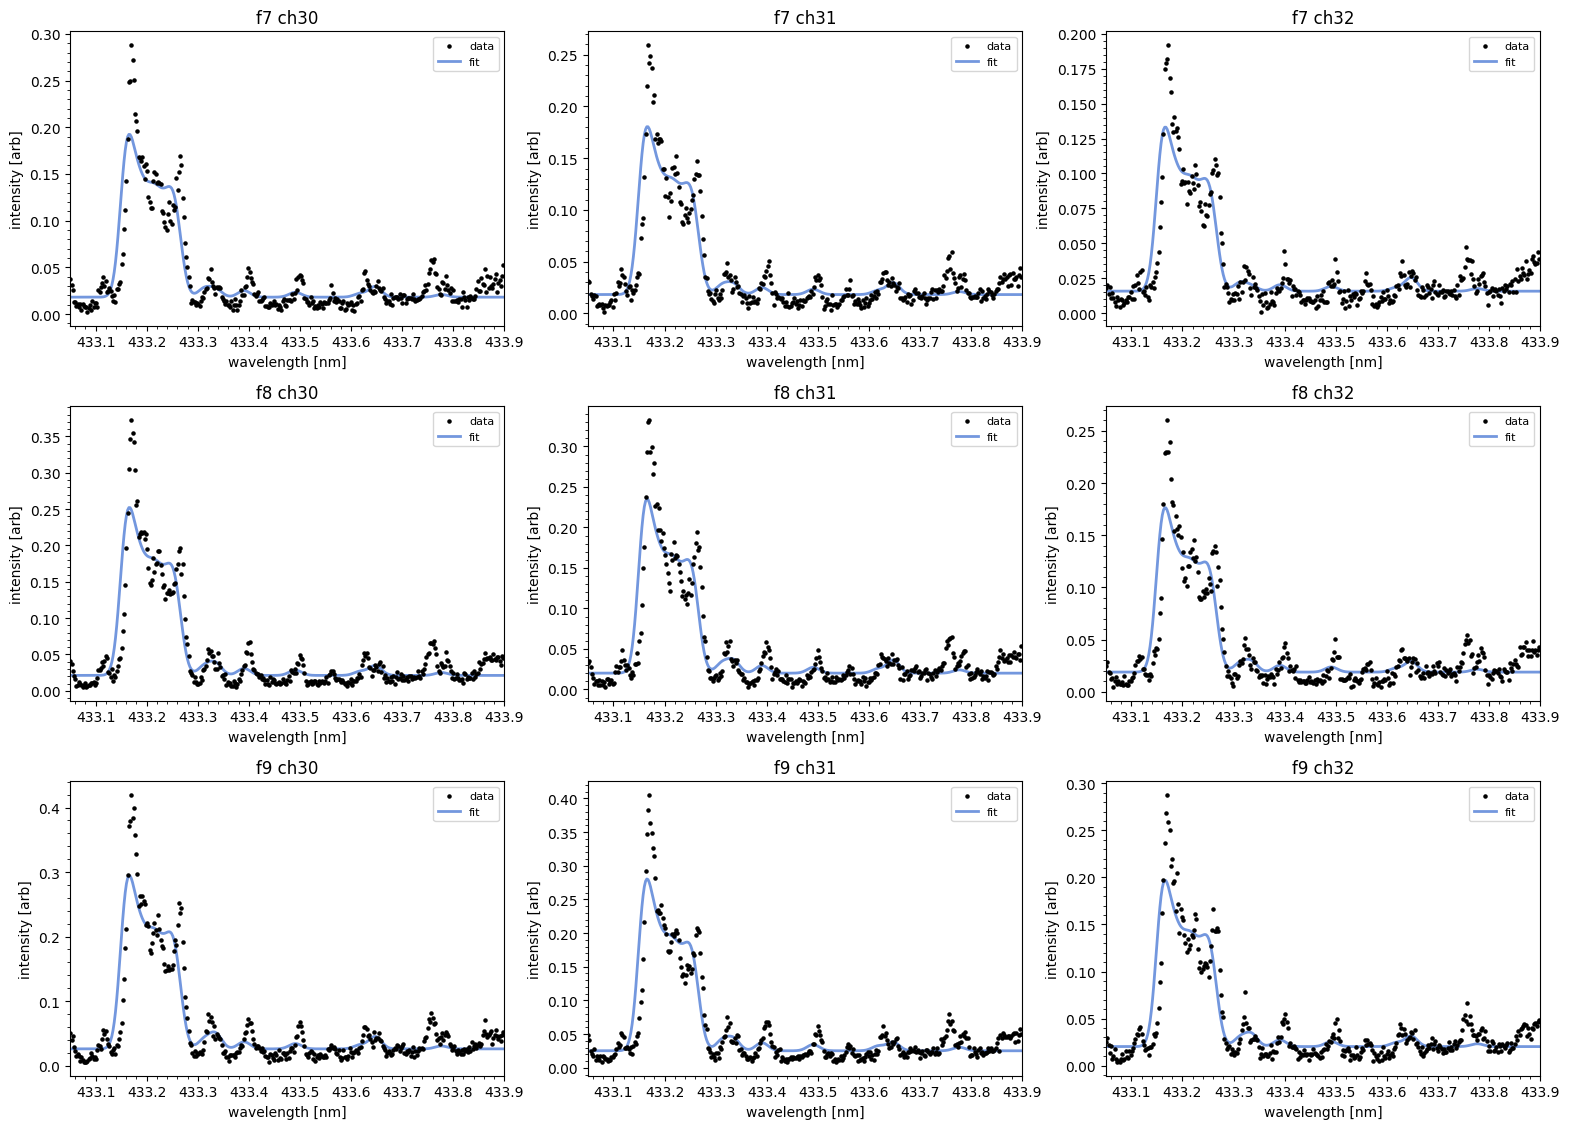

In [21]:
_ = fitr.plot_grid(curves)